In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

442
ARIMA 732
Prophet 732
TimeSeers 732
Vangja hierarchical 732
Vangja from posterior 732
Vangja combined 732
ETS 732
UC 732


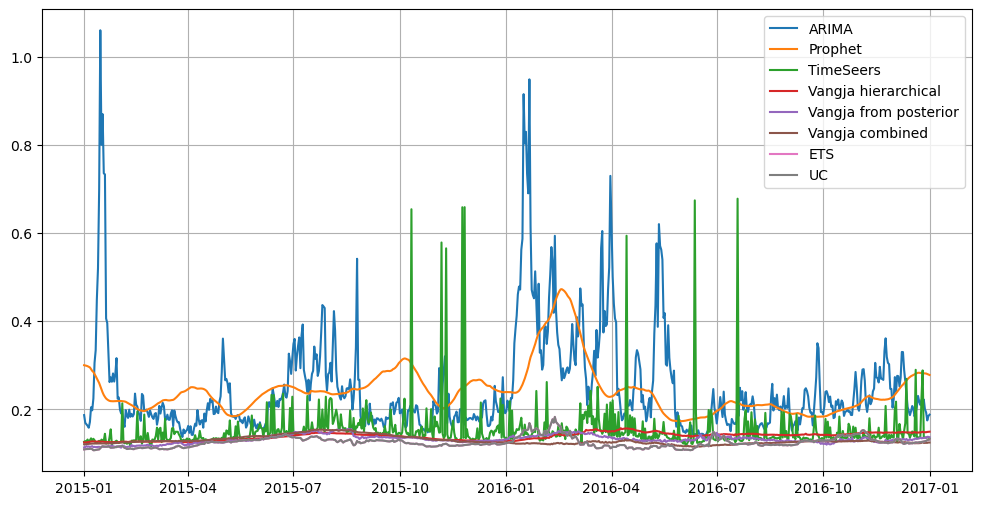

In [11]:
parent_path = Path("./") / "out"

paths = [
    parent_path / "arima",
    parent_path / "prophet" / "test2",
    parent_path / "timeseers" / "model_4",
    parent_path / "h_prophet_1" / "model_6",
    parent_path / "vangja2" / "model_5",
    parent_path / "h_vangja_tune_delta_complete" / "model_3",
    parent_path / "es",
    parent_path / "uc",
]
labels = [
    "ARIMA",
    "Prophet",
    "TimeSeers",
    "Vangja hierarchical",
    "Vangja from posterior",
    "Vangja combined",
    "ETS",
    "UC",
]
index = None

for point in pd.date_range("2015-01-01", "2017-01-01"):
    point_str = f"{point.year}-{'' if point.month > 9 else '0'}{point.month}-{'' if point.day > 9 else '0'}{point.day}"
    model_name = f"{point_str}"
    csv_path = paths[0] / f"{model_name}.csv"
    vangja_path = paths[4] / f"{point_str}.csv"
    if not csv_path.is_file() or not vangja_path.is_file():
        print(csv_path, vangja_path)
        continue

    index_1 = pd.read_csv(csv_path, index_col=0).index
    index_2 = pd.read_csv(vangja_path, index_col=0).index
    index_1 = index_1.intersection(index_2)
    if index is None:
        index = index_1

    index = index.intersection(index_1)

print(len(index))
plt.figure(figsize=(12, 6))

for idx, (path, label) in enumerate(zip(paths, labels)):
    dates = []
    mapes = []
    for point in pd.date_range("2015-01-01", "2017-01-01"):
        point_str = f"{point.year}-{'' if point.month > 9 else '0'}{point.month}-{'' if point.day > 9 else '0'}{point.day}"
        csv_path = (
            path / f"prophet_{point_str}_multiplicative_lt0_w.csv"
            if idx == 1
            else path / f"{point_str}.csv"
        )

        if not csv_path.is_file():
            continue

        dates.append(point)
        mapes.append(pd.read_csv(csv_path, index_col=0)["mape"].mean())

    print(label, len(dates))
    # plt.plot(dates, mapes, label=f"{label} ~ {100 * sum(mapes) / len(mapes):.2f}")
    plt.plot(dates, mapes, label=label)

plt.grid()
plt.legend()

In [13]:
from vangja.data_utils import (
    download_data,
    generate_train_test_df_around_point,
    process_data,
)

dfs = download_data(Path("./data"))
indexes = process_data(dfs[0])
smp = [index for index in indexes if index["series"].iloc[0] == "^GSPC"]
gspc_tickers = process_data(dfs[1])

In [ ]:
def plot(train, test, pred):
    train_dates = train["ds"].dt.date
    train_values = train["y"]
    test_dates = test["ds"].dt.date
    test_values = test["y"]
    pred_dates = pred.index
    pred_values = pred.values
    plt.figure(figsize=(12, 6))
    plt.plot(train_dates, train_values, label="Train set", color="blue")
    plt.plot(test_dates, test_values, label="Test set", color="green")
    plt.plot(pred_dates, pred_values, label="Forecasts", color="orange")
    plt.grid()
    plt.legend()

/home/jovan/miniconda3/envs/pymc_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


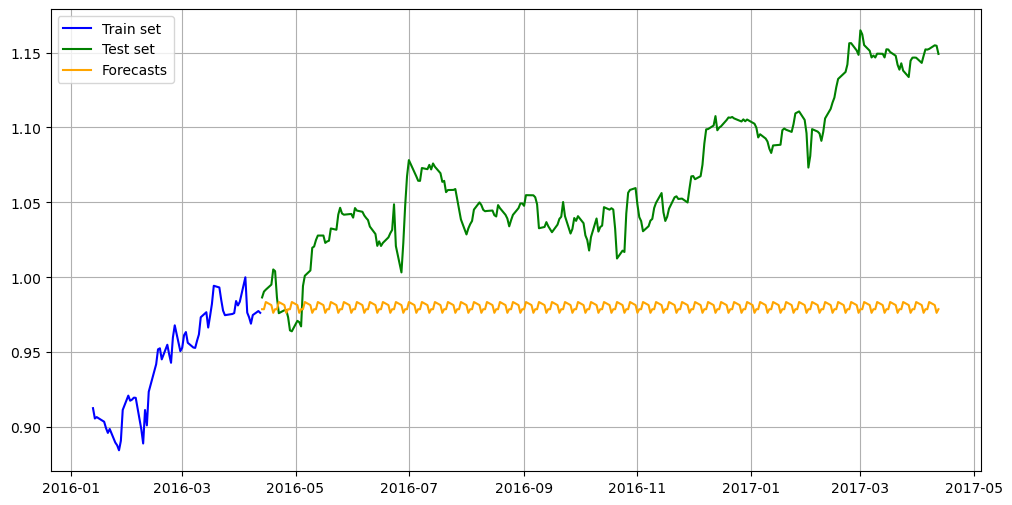

In [15]:
from sktime.forecasting.exp_smoothing import ExponentialSmoothing
from sktime.forecasting.base import ForecastingHorizon

gspc_ticker = [ticker for ticker in gspc_tickers if ticker["series"].iloc[0] == "CB"][0]
train_df_tickers, test_df_tickers, scales_tickers = generate_train_test_df_around_point(
    window=91,
    horizon=365,
    dfs=[gspc_ticker],
    for_prophet=False,
    point="2016-04-13",
)
y_train = train_df_tickers.set_index("ds")["y"]
fh = ForecastingHorizon(
    test_df_tickers.set_index("ds").index, is_relative=False
)
es_forecaster = ExponentialSmoothing(seasonal="additive", sp=7)
es_forecaster.fit(y=y_train)
y_pred_es = es_forecaster.predict(fh=fh)

plot(train_df_tickers, test_df_tickers, y_pred_es)

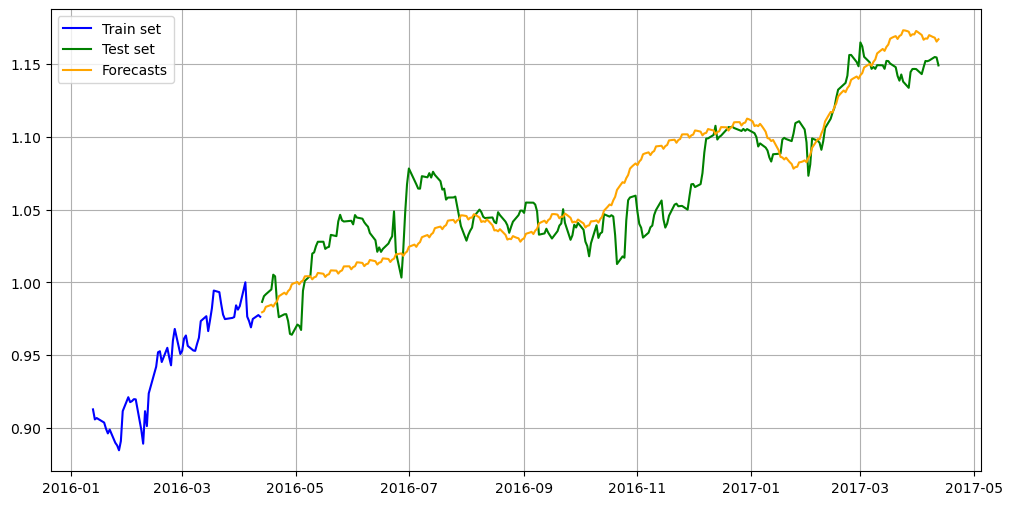

In [17]:
vangja_preds = pd.read_csv("predictions2/2016-04-13_CB.csv", index_col=0)
plot(
    train_df_tickers,
    test_df_tickers,
    pd.DataFrame(vangja_preds["yhat_70"].to_list(), index=y_pred_es.index)[0],
)